# ESCI Verification with LLMs: Prompt Testing

### Step 0: Data Audit and Labeling
1. Looked through the 2 datasets
2. Confirmed locale and product id form a unique identifier to join the 2 tables on 
3. Labeled data for the query given queries 

### Step 1: Data Loading and Preparation

1. Raw data: 2.6M query-product judgements and 1.8M product records
2. Merging: Join on ['product_locale', 'product_id'] to get full context (title, bullets, brand) for every judgement
   1. Confirmed that this combination forms a unique identifier for a product record since same product can exist in multiple locales with different descriptions (confirmed in first jupyter)
3. Filtering: Filter on target queries and ESCI_Label = 'E'

In [1]:
from src.llm import ModelEvaluator
from src.prompts import EVALUATION_PROMPT_V2, EVALUATION_PROMPT
from src.evalution import run_experiment, score_against_human
from src.data_loader import load_raw_data, merge_examples_products, filter_dataset
from src.schemas.response_schema import MyResponse, MyResponseReordered
from src.evalution import show
from pathlib import Path
import pandas as pd

In [2]:
df_examples, df_products = load_raw_data('../data/raw')
df_merged = merge_examples_products(df_examples, df_products)
subset = filter_dataset(df_merged)
random_sample_df = df_merged[df_merged.esci_label =='E'].sample(5, random_state=42)

# subset = pd.read_csv('../data/processed/subset_to_review.csv')

In [3]:
manual_labels = pd.read_csv('../data/processed/my_manual_labels.csv')

### Step 2: Prompt Engineering

#### V1 Prompt: Basic prompt with Gemma3:4b

**Key Design Decision**: 
1. Instead of asking the LLM a simple yes/no for conflict, our prompt forces a structured, chain of thought output structure
   1. This forces the model to think through the query attributes, followed by the prompt attributes, and then think about conflict and if we need to reformulate the query
2. Use of LiteLLM as a wrapper - this allows to easily swap out models and try multiple ones out
3. Use of Pydantic schemas being passed to the model 
4. Helper functions to help compare model performance with human labels

Our schema MyResponse forces the LLM to output strict JSON:
1. **Feature Extraction**: Parse the query into individual specs (example: ["aa batteries", "100 pack"])
2. **Product Alignment**: Extract the corresponding features from product text 
3. **Conflict Detection**: Evaluate the rules
4. **Acceptability**: ~ conflict found
5. **Reformulation**: If not an exact match, suggest a reformulated query that makes it a true match for that product

In [4]:
if Path('../data/processed/gemma_labels_v0.csv').exists():
    v0_labels = pd.read_csv('../data/processed/gemma_labels_v0.csv')
    v0_random_sample_labels = pd.read_csv('../data/processed/gemma_random_labels_v0.csv')
else:
    gemma_v0 = ModelEvaluator(temperature=0)
    v0_labels = run_experiment(subset, gemma_v0, 'gemma_labels_v0')
    v0_random_sample_labels = run_experiment(random_sample_df, gemma_v0, 'gemma_random_labels_v0')

merged_data = pd.merge(
    v0_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)

##### When does the model go wrong? 
1. Flag an interesting case where product title says 100 count, but bullet points say 50 count, but model counts this as extra info and not a contradiction
2. Model flags conflict, even while reasoning that there is none 
3. NaNs due to error while calling the model (Could fix this with retries built in)

In [6]:
# Wrong cases 
show(merged_data[merged_data.conflict_found != merged_data.Conflict_Found_GT])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
5,142661,aa batteries 100 pack,Energizer AA Max Alkaline E91 Batteries Made in USA - Expiration 12/2024 or Later - 100 Count,S,True,False,"The query asks for ""aa batteries 100 pack"". The product explicitly states ""Energizer MAX AA batteries 50 count"", but the product also states ""100 count"". Since the product includes the quantity, we assume it is a match. The product also includes the brand name ""Energizer"" which is present in the query.",nan,nan
10,660833,"dewalt 8v max cordless screwdriver kit, gyroscopic","DEWALT DCF680N2 8V Max Gyroscopic Screwdriver 2 Battery Kit with DEWALT DWST08201 Tough System Case, Small",E,False,True,"The query explicitly asks for an 8v max cordless screwdriver kit. The product title and bullet points confirm this, stating ""DEWALT DCF680N2 8V Max Gyroscopic Screwdriver 2 Battery Kit"".","dewalt 8v max cordless screwdriver 2 battery kit, gyroscopic",nan
12,660840,"dewalt 8v max cordless screwdriver kit, gyroscopic","DEWALT 8V MAX Cordless Screwdriver Kit, Gyroscopic, 2 Batteries, Electric (DCF680N2)",E,False,True,"The query specifies an 8v max kit. The product explicitly states it is an 8V MAX Cordless Screwdriver Kit. No contradiction on ""gyroscopic"" so we leave it in the reformulated query.","dewalt 8v max cordless screwdriver kit, gyroscopic",nan
21,1163641,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11” (8318164)",S,True,False,"The query asks for glossy photo paper, but the product is matte finish. There is no contradiction on the size or quantity. The brand name is also correct. Therefore, it is a match.",nan,nan


##### Issues to highlight here

1. Conflict found and acceptable can sometimes be in disagreement
2. Found a case where product contains matte finish but matches with glossy and model still says it is acceptable 
3. Even if no conflict found, gemma still creates a reformulated query

In [7]:
# merged_data[merged_data.conflict_found == merged_data.acceptable].head(1)

              precision    recall  f1-score   support

 No Conflict       0.88      0.88      0.88        17
    Conflict       0.71      0.71      0.71         7

    accuracy                           0.83        24
   macro avg       0.80      0.80      0.80        24
weighted avg       0.83      0.83      0.83        24



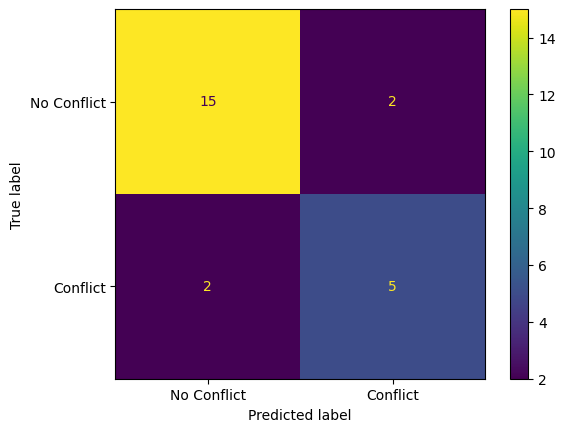

In [8]:
score_against_human(merged_data)

In [9]:
# Checking a random sample
show(v0_random_sample_labels, display_cols= ["example_id", "query", "title", "conflict_found", "reasoning", "reformulated_query", "error"])

,example_id,query,title,conflict_found,reasoning,reformulated_query,error
0,2498421,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,False,"The query is asking for a '収納ボックス' (storage box). The product title clearly states it is a 'チェスト ワイド 3段' (wide 3-tier chest), which is a type of storage box. There is no contradiction.",チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,nan
1,706866,dr martens mujer plataforma,"Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro",False,"The query asks for ""dr martens mujer plataforma"". The product explicitly states ""These platform boots..."" and ""5 cm heel and 3.5 cm platform"", so there is no contradiction. The query also includes ""mujer"" which is present in the product title and description.",nan,nan
2,1982138,tempered glass privacy screen iphone xr,"Hizansa [2 Pack] iPhone Xs Max Screen Protector,6D Tempered Glass Screen Protector for iPhone Xs Max (iPhone Xs Max)",False,"The product is designed for iPhone Xs Max, not iPhone XR. The query asks for an iPhone XR screen. This is a difference in device model, not a contradiction of features. The product includes tempered glass and privacy screen, which are present in the query. The product also includes features like 9H hardness, anti-fingerprint coating, and shatter-proof, which are present in the query. The product also includes ""double defense technology"" which is present in the query. The product does not explicitly state that it is a privacy screen, but the product description mentions ""protects sensors and front camera"" which is a common feature of privacy screens. Therefore, there is no contradiction.",tempered glass privacy screen iphone xs max,nan
3,313103,belly button rings,EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry,False,"The query asks for 'belly button rings'. The product description explicitly states '15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry'. There is no contradiction, so it is a match.",nan,nan
4,2512267,存在のたえられない軽さ,存在の耐えられない軽さ(字幕版),False,The query and product share the same title. There is no contradiction.,nan,nan


#### V1 Prompt: Basic prompt with Qwen2:7b

**Key Design Decision**: 
1. Model changed from gemma3:4b to qwen2:7b
2. Schema changes:
   1. Re-order reasoning to happen before conflict_found decision is made by the model - this further helps the model reason and make a better decision
   2. Remove redundant acceptability check (which is NOT(conflict_found) anyways)

Our schema MyResponse forces the LLM to output strict JSON:
1. **Feature Extraction**: Parse the query into individual specs (example: ["aa batteries", "100 pack"])
2. **Product Alignment**: Extract the corresponding features from product text 
3. **Conflict Detection**: Evaluate the rules
4. **Acceptability**: ~ conflict found
5. **Reformulation**: If not an exact match, suggest a reformulated query that makes it a true match for that product

Processing:   0%|          | 0/24 [00:00<?, ?it/s]

Processing: 100%|██████████| 5/5 [04:30<00:00, 54.19s/it]

              precision    recall  f1-score   support

 No Conflict       0.89      0.94      0.91        17
    Conflict       0.83      0.71      0.77         7

    accuracy                           0.88        24
   macro avg       0.86      0.83      0.84        24
weighted avg       0.87      0.88      0.87        24



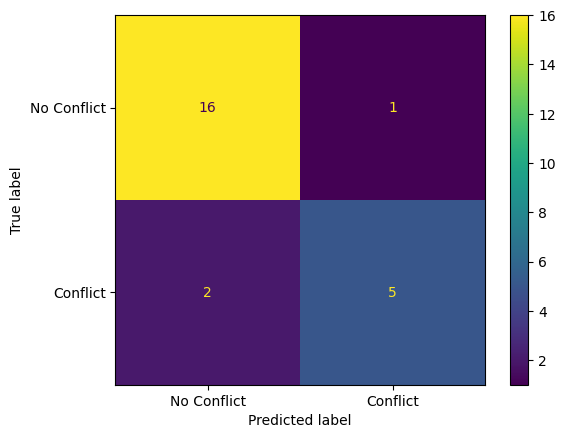

In [10]:
if Path('../data/processed/qwen_labels_v0.csv').exists():
    v0_qwen_labels = pd.read_csv('../data/processed/qwen_labels_v0.csv')
    v0_random_sample_labels_qwen = pd.read_csv('../data/processed/qwen_random_labels_v0.csv')
else:
    qwen_v0 = ModelEvaluator(
        model_name='ollama/qwen2:7b', temperature=0, response_schema=MyResponseReordered, 
        system_prompt=EVALUATION_PROMPT_V2, num_retries=2, timeout=300)
    v0_qwen_labels = run_experiment(subset, qwen_v0, 'qwen_labels_v0')
    v0_random_sample_labels_qwen = run_experiment(random_sample_df, qwen_v0, 'qwen_random_labels_v0')

merged_data_qwen = pd.merge(
    v0_qwen_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)
score_against_human(merged_data_qwen)

In [19]:
v0_qwen_labels[v0_qwen_labels.example_id==142661].product_features.iloc[0]

['Energizer AA Max Alkaline E91 Batteries',
 'Made in USA - Expiration 12/2024 or Later',
 '100 Count',
 "World's 1st Zero Mercury AA Alkaline Battery",
 'Up to 10 years shelf life',
 'Bulk Packaging',
 'Brand: Energizer']

In [11]:
show(merged_data_qwen[merged_data_qwen.conflict_found != merged_data_qwen.Conflict_Found_GT])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
5,142661,aa batteries 100 pack,Energizer AA Max Alkaline E91 Batteries Made in USA - Expiration 12/2024 or Later - 100 Count,S,True,False,"The query asks for 'aa batteries' and a '100 pack'. The product information explicitly states that it is an 'Energizer AA Max Alkaline E91 Batteries', which matches the battery type specified in the query. Additionally, the product title mentions '100 Count', directly matching the quantity requested by the user. There are no contradictions between the query and the product features provided.",nan,None
7,142666,aa batteries 100 pack,"Amazon Basics 100 Pack AAA High-Performance Alkaline Batteries, 10-Year Shelf Life, Easy to Open Value Pack",E,False,True,"The query specifies 'aa batteries' and '100 pack'. The product title mentions '100 Pack', which matches the quantity specified in the query. However, the product does not explicitly state that it is 'aa' batteries; instead, it states 'AAA High-Performance Alkaline Batteries'. This creates a conflict because the attribute type (battery size) contradicts the query's request for 'aa batteries'.",aa batteries 100 pack,None
21,1163641,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11” (8318164)",S,True,False,"The query specifies 'kodak', which matches the product's brand name. The size is specified as 8.5 x 11 inches and the finish is glossy, both of which match the product features. There is no explicit mention of a matte finish in the query or product description, but since the product has a 'Matte Finish' bullet point, it can be assumed that this feature was not contradicted by the query. The color mentioned in the query ('glossy') does not directly contradict any information provided about the product's finish (which is described as matte). Therefore, there are no explicit contradictions between the query and the product features.",nan,None


In [12]:
show(merged_data[merged_data.example_id == 1163641])

,example_id,query,title,human_label,Conflict_Found_GT,conflict_found,reasoning,reformulated_query,error
21,1163641,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte Finish, 7 mil thickness, 100 sheets, 8.5” x 11” (8318164)",S,True,False,"The query asks for glossy photo paper, but the product is matte finish. There is no contradiction on the size or quantity. The brand name is also correct. Therefore, it is a match.",nan,nan


Issues here: 
1. Model now still makes 4 mistakes, but in all mistakes it always says no conflict, when there is a conflict
2. And in those cases the model does not have any reasoning? 
3. When tried on a random sample that is in another language, it generates output in that same language --maybe we want English 

In [ ]:
v0_qwen_labels

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,reformulated_query,latency_sec,error
0,2498421,E,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm...,アイリスオーヤマ(IRIS OHYAMA),サイズ(約):幅54×奥行40×高さ62.5cm ※ローラー取付時 引出内寸(約):幅48....,[収納ボックス],[チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / ...,False,The query is asking for a '収納ボックス' (storage bo...,チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / ク...,25.05,None


In [14]:
# Checking a random sample
show(v0_random_sample_labels_qwen, display_cols= ["example_id", "query", "title", "conflict_found", "reasoning", "reformulated_query", "error"])

,example_id,query,title,conflict_found,reasoning,reformulated_query,error
0,2498421,収納ボックス,アイリスオーヤマ チェスト ワイド 3段 日本製 完成品 幅54×奥行40×高さ62.5cm ホワイト / クリア 白 プラスチック天板 W-543,False,"The query '収納ボックス' directly matches the product title which also mentions '収納の目安', indicating storage capacity. The product features include dimensions, weight, material composition and storage capacity guidelines that are consistent with the query's intent for a storage box. There is no explicit contradiction in the provided information.",None,None
1,706866,dr martens mujer plataforma,"Botas para mujer, color Negro , marca DR. MARTENS, modelo Botas Para Mujer DR. MARTENS SINCLAIR 8 EYE AUNT S Negro",False,"The query specifies 'dr martens', 'mujer' (female) and 'plataforma' (platform). The product information matches the brand name 'DR. MARTENS', indicates that it's for 'mujer' (female), mentions 'plataforma' in its description, confirming the platform feature. There are no explicit contradictions between the query features and the product features provided.",None,None
2,1982138,tempered glass privacy screen iphone xr,"Hizansa [2 Pack] iPhone Xs Max Screen Protector,6D Tempered Glass Screen Protector for iPhone Xs Max (iPhone Xs Max)",False,"The query asks for a 'privacy screen' which is not mentioned in the product features. The product title mentions it's designed for iPhone Xs Max, but not specifically iPhone XR as requested by the query. Also, there is no mention of 'tempered glass privacy screen' in the product description.",None,None
3,313103,belly button rings,EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings for Women Girls CZ Screw Navel Bars Body Piercing Jewelry,False,"The query asks for 'belly button rings'. The product information provided includes the exact phrase 'EVELICAL 15Pcs 14G Stainless Steel Belly Button Rings', which matches the query. There are no other attributes specified in the query that need to be matched against the product features, and there is no explicit contradiction found within the product description or bullet points.",None,None
4,2512267,存在のたえられない軽さ,存在の耐えられない軽さ(字幕版),False,ユーザーのクエリは「存在のたえられない軽さ」で、製品情報は「存在の耐えられない軽さ（字幕版）」です。クエリと製品タイトルの主要な違いは、「たえられない」が「耐えられない」に変更され、それによりコンフリクトが発生します。「字幕版」は両方とも一致しています。しかし、このコンフリクトは単語の意味が異なるためであり、クエリと製品タイトルの主要な情報（「存在の」部分）は一致しているため、これはコンフリクトとして見なし切れません。,None,None


In [ ]:
# model="gemini/gemini-2.5-flash",